<a href="https://colab.research.google.com/github/jayprich/maze-generator-with-guidance/blob/main/maze_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
try(loadNamespace("container"))
if(!isNamespaceLoaded("container")) {
    print("installing Package 'container' ..")
    install.packages("container")
    loadNamespace("container")
}

<environment: namespace:container>

In [38]:
# note the outer border of visited "1L" cells
cell_size <- 301
grid_size <- 2*cell_size+3
offsets <- c(-grid_size, 1, grid_size, -1)
canvas <- data.table::as.data.table( c(rep(1L, grid_size), rep(c(1L, rep(0L, grid_size-2), 1L), grid_size-2), rep(1L, grid_size)) )

In [39]:
mask <- data.table::as.data.table( rep(0L, grid_size*grid_size) )
pattern <- c(0,2,grid_size-1,grid_size+3,3*grid_size-1,3*grid_size+3,4*grid_size,4*grid_size+2)

if(T){  # make some obstacles
for(i in 1:ceiling(cell_size*cell_size/30)){
    x <- sample.int(cell_size-2, 1)-1
    y <- sample.int(cell_size-2, 1)-1
    mask[2*y*grid_size+2*x+pattern] <- 1L
}
}
#image(matrix(mask,grid_size))

In [40]:
move <- function(loc, canvas) {
    good_offsets <- offsets[which(canvas$V1[loc+offsets]+canvas$V1[loc+2*offsets]==0)]
    if(length(good_offsets) == 0){
        good_offsets <- offsets[which(canvas$V1[loc+2*offsets]==0)]
        if(length(good_offsets) == 0){
            return(NULL)
        }
    }
    if(length(good_offsets) == 1){
        return(good_offsets)
    }
    sample(good_offsets, 1)
}

In [41]:
if(F){ # skip to Rcpp implementation
# temporary mask
canvas <- canvas+mask

# grow spanning tree from a central cell
loc <- 1+2*ceiling(cell_size/2)*(1+grid_size)
data.table::set(canvas, loc, 1L, 1L) # canvas[loc] <- 1L

# depth first search backtrack
visits <- container::cont()

#profvis::profvis({
repeat {
    m <- move(loc, canvas)
    if (is.null(m)) {
        loc <- container::ref_pop(visits) # backtrack
    } else {
        container::ref_add(visits, loc) # push
        loc <- loc + m
        data.table::set(canvas, loc, 1L, 1L) # path crosses wall
        data.table::set(mask, loc, 1L, 0L) # cannot be masked
        loc <- loc + m
        data.table::set(canvas, loc, 1L, 1L)
    }
    if (container::is_empty(visits)) {
        break
    }
}

#}, prof_output="Rprof.out")
#summaryRprof()

# remove the mask
canvas <- canvas-mask
}

MAZE cf771373

In [42]:
# reset the canvas
canvas <- data.table::as.data.table( c(rep(1L, grid_size), rep(c(1L, rep(0L, grid_size-2), 1L), grid_size-2), rep(1L, grid_size)) )

# masking dealt internally by Rcpp

loc_start <- 1+2*ceiling(cell_size/2)*(1+grid_size)

#profvis::profvis({
canvas$V1 <- cpp_generate_maze(loc_start, canvas$V1, mask$V1, offsets, grid_size)
#}, prof_output="Rprof.out")
#summaryRprof()

Re-visualize the final maze (cell xlVVg0YIaaA-).

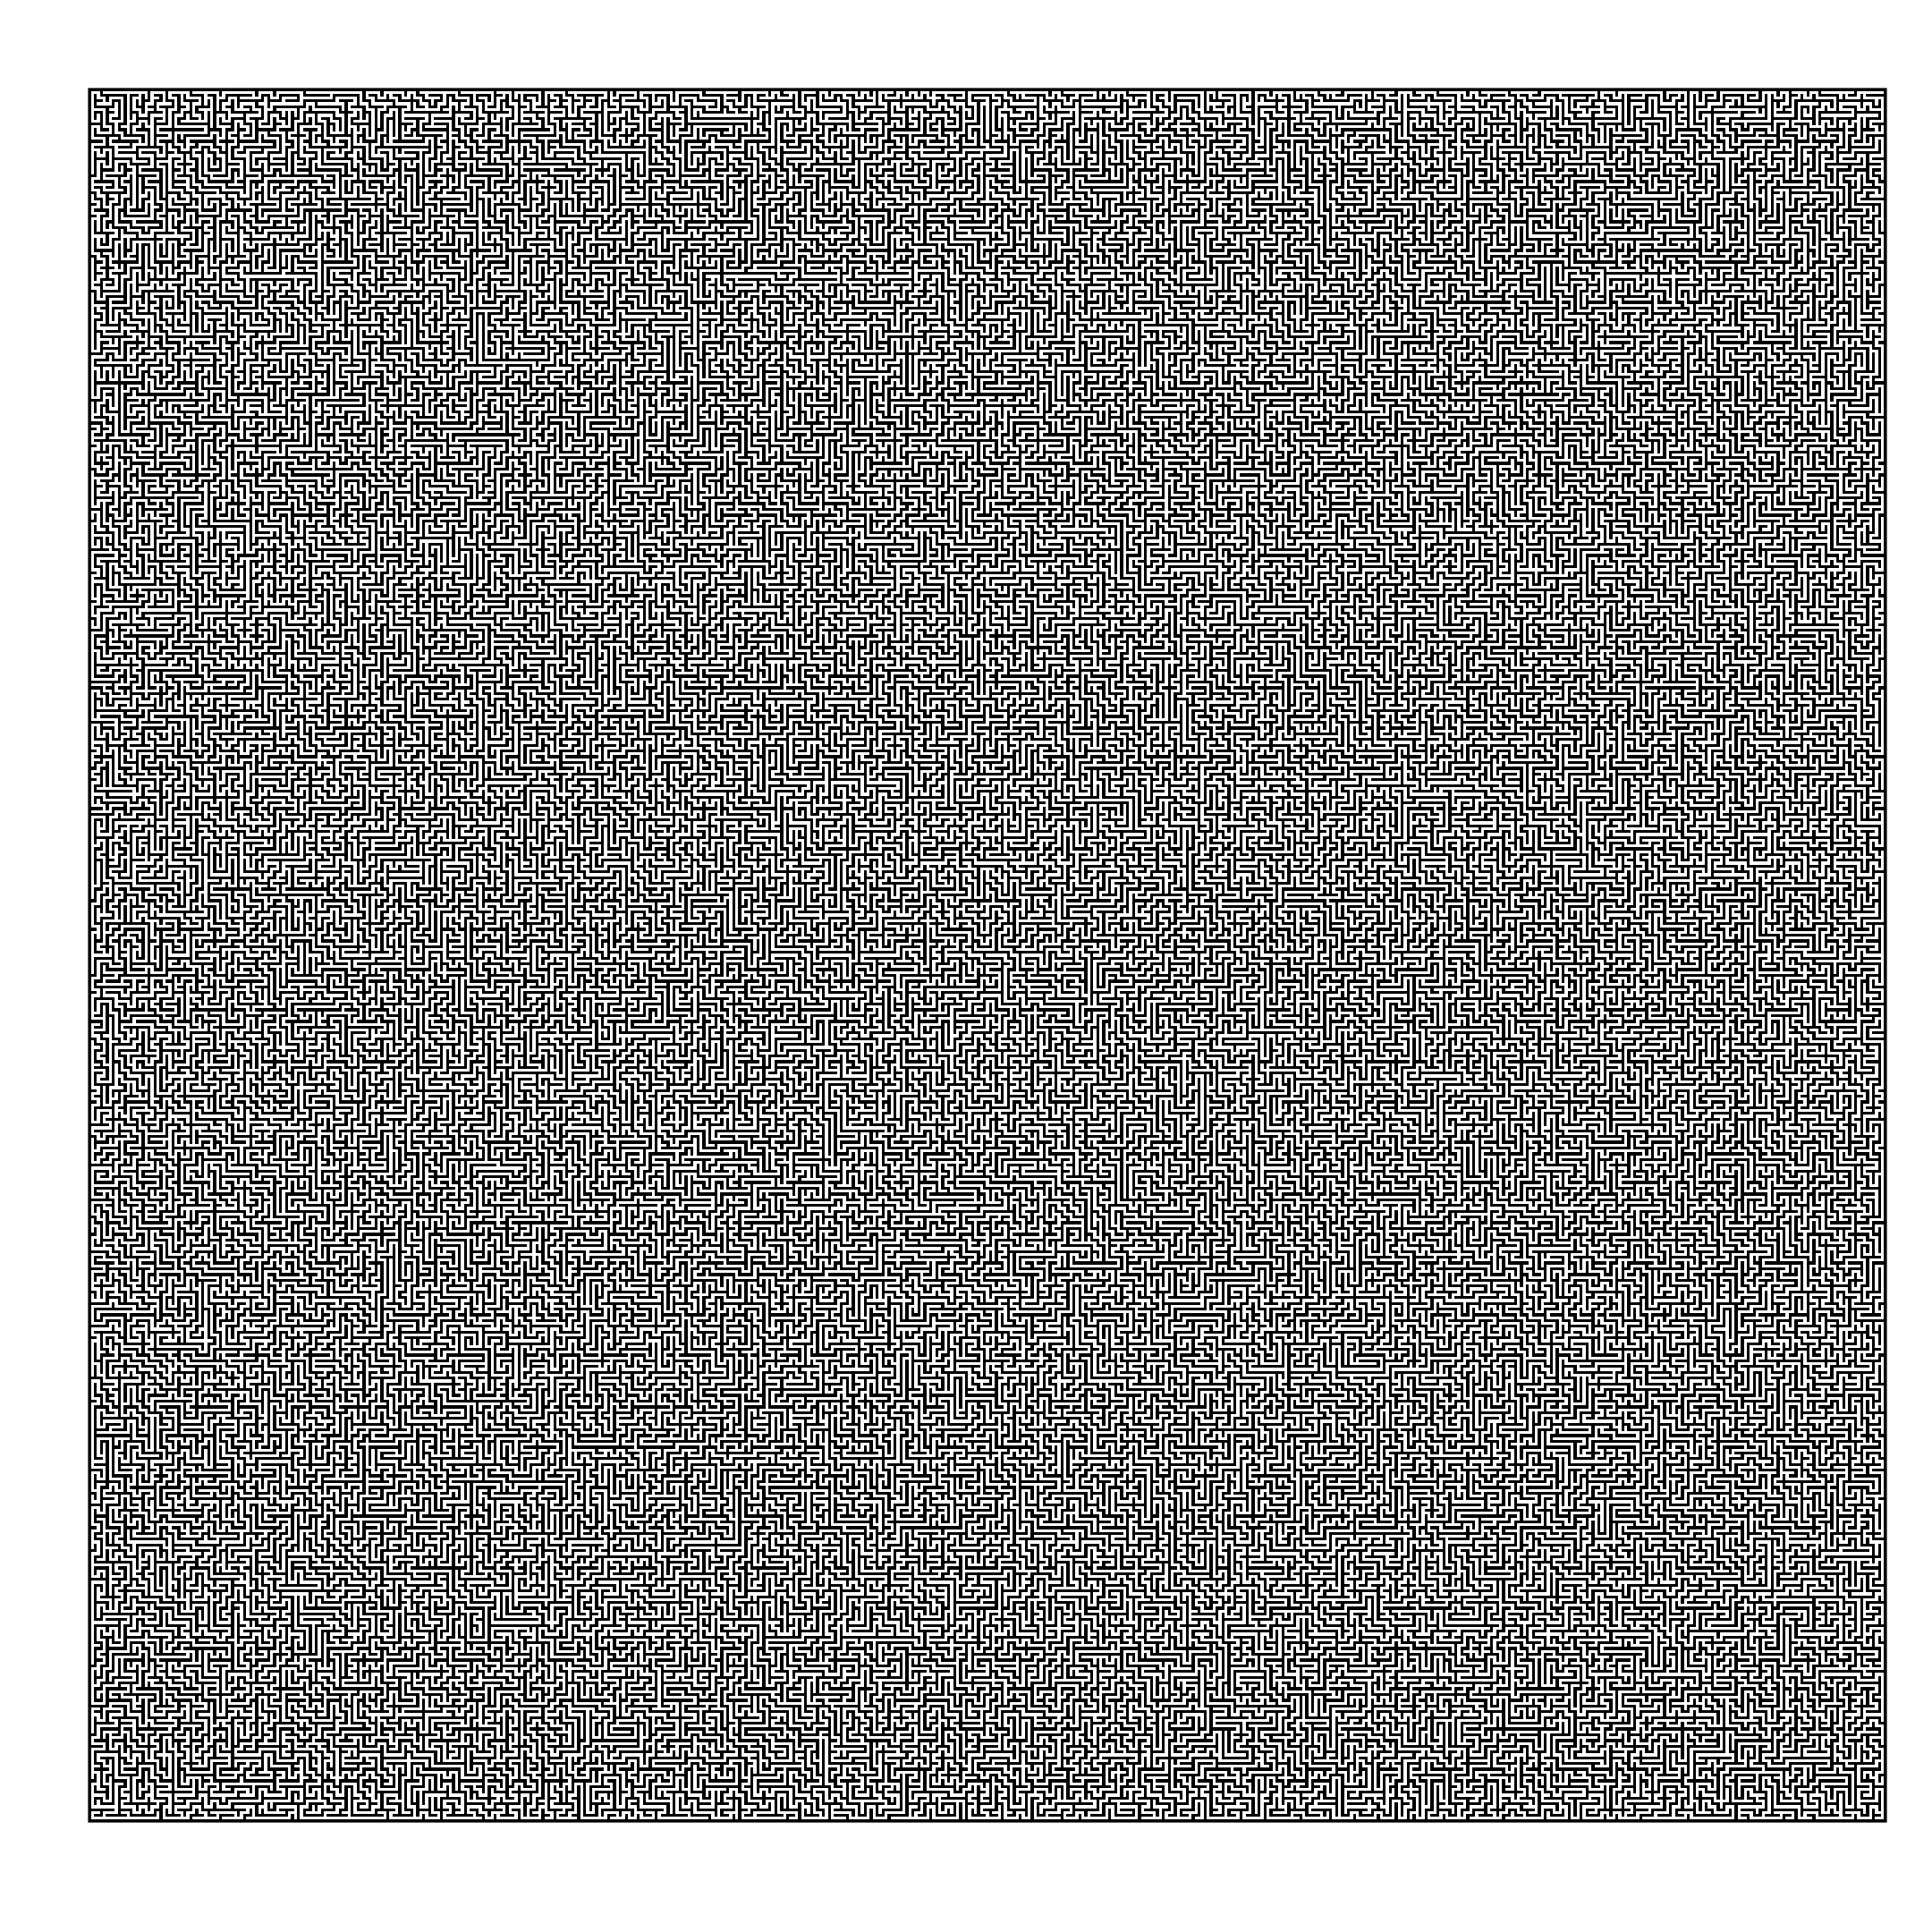

In [43]:
options(repr.plot.width=18, repr.plot.height=18)
image(matrix(1L-canvas[[1]],grid_size)[2:(grid_size-1),2:(grid_size-1)],col=c(0,10,1),axes=F)

In [44]:
# slower but higher quality plot
if(F){
options(repr.plot.width=9, repr.plot.height=9)
plot.new()
plot.window(xlim = c(1, 1+cell_size), ylim = c(1, 1+cell_size), asp = 1)

for (y in 1:(cell_size+1)) {
  for (x in 1:cell_size) {
    if (canvas[(2*y-1)*grid_size+2*x+1]==0L) {
      segments(x, y, x+1, y, lwd = 1)
    }
  }
}

for (y in 1:cell_size) {
  for (x in 1:(cell_size+1)) {
    if (canvas[2*y*grid_size+2*x]==0L) {
      segments(x, y, x, y+1, lwd = 1)
    }
  }
}

title("Generated Maze")
}

In [45]:
# Write the C++ code to a temporary file
cpp_code_content <- "
#include <Rcpp.h>
#include <vector>
#include <random>

// [[Rcpp::export]]
Rcpp::IntegerVector cpp_generate_maze(  int loc_start,
                        Rcpp::IntegerVector canvas_V1_orig,
                        Rcpp::IntegerVector mask_V1_orig,
                        Rcpp::IntegerVector offsets,
                                        int grid_size){

Rcpp::IntegerVector canvas = Rcpp::clone(canvas_V1_orig);
Rcpp::IntegerVector mask = Rcpp::clone(mask_V1_orig);

for (int i = 0; i < canvas.size(); ++i) {
    canvas[i] += mask[i];
}

int c_loc = loc_start - 1;

canvas[c_loc] = 1;

std::vector<int> visits_stack;

while (true) {
    std::vector<int> current_good_offsets;

    for (int i = 0; i < offsets.size(); ++i) {
        int offset = offsets[i];
        int idx_offset = c_loc + offset;
        int idx_2offset = c_loc + 2 * offset;

        if (idx_offset >= 0 && idx_offset < canvas.size() &&
            idx_2offset >= 0 && idx_2offset < canvas.size()) {
            if (canvas[idx_offset] + canvas[idx_2offset] == 0) {
                current_good_offsets.push_back(offset);
            }
        }
    }

    if (current_good_offsets.empty()) {
       for (int i = 0; i < offsets.size(); ++i) {
         int offset = offsets[i];
          int idx_2offset = c_loc + 2 * offset;

          if (idx_2offset >= 0 && idx_2offset < canvas.size()) {
            if (canvas[idx_2offset] == 0) {
              current_good_offsets.push_back(offset);
          }
        }
      }
    }

    int m_val;
    if (current_good_offsets.empty()) {
      m_val = R_NaInt;
    } else if (current_good_offsets.size() == 1) {
      m_val = current_good_offsets[0];
    } else {
      Rcpp::IntegerVector good_offsets_R = Rcpp::wrap(current_good_offsets);
      m_val = Rcpp::as<int>(Rcpp::sample(good_offsets_R, 1, false));
    }

    if (m_val == R_NaInt) {
      if (visits_stack.empty()) {
        break;
      }
      c_loc = visits_stack.back();
      visits_stack.pop_back();
    } else {
      visits_stack.push_back(c_loc);
      c_loc += m_val;
      canvas[c_loc] = 1;
      mask[c_loc] = 0;

      c_loc += m_val;
      canvas[c_loc] = 1;
    }
  }

  for (int i = 0; i < canvas.size(); ++i) {
    canvas[i] -= mask[i];
  }

  return canvas;
}"

temp_cpp_file <- tempfile(fileext = ".cpp")
writeLines(cpp_code_content, temp_cpp_file)

In [46]:
if(T){   # compile and load the function
Rcpp::sourceCpp(temp_cpp_file)
}

### Explanation of the `cpp_generate_maze` function:

1.  **`Rcpp::cppFunction(...)`**: Compiles the C++ code and makes the `cpp_generate_maze` function available in your R session.
2.  **Function Signature**: Takes the starting `loc`, original `canvas$V1`, original `mask$V1`, `offsets`, and `grid_size` as inputs. It returns the final modified `canvas` as an `Rcpp::NumericVector`.
3.  **Writable Copies**: `Rcpp::clone` is used to create independent, writable copies of `canvas_V1_orig` and `mask_V1_orig` within the C++ function, so the original R objects are not modified directly until the final result is assigned back.
4.  **Mask Handling**: The initial `canvas <- canvas + mask` and final `canvas <- canvas - mask` operations are performed directly within the C++ loops.
5.  **DFS Loop in C++**: The entire maze generation `repeat` loop, including the `move` logic and stack operations, is translated into C++. `std::vector<int> visits_stack;` acts as the `container::cont()`.
6.  **Direct Array Access**: Instead of `data.table::set()`, which involves R overhead, `canvas[c_loc] = 1;` and `mask[c_loc] = 0;` are used for direct 0-based indexing and modification of the C++ vectors, ensuring maximum performance.
7.  **Random Sampling**: `Rcpp::sample` is used for random selection, leveraging R's random number generator but handling the data types efficiently within C++.
8.  **Return Value**: The function returns the final, processed `canvas` vector, which can then be assigned back to your `data.table` in R.

### Step 1: Load and Preprocess the Input Image

To align the maze walls with an input photograph, we first need to load the image, convert it to grayscale, and resize it to a resolution that is manageable and corresponds to our maze's `cell_size`.

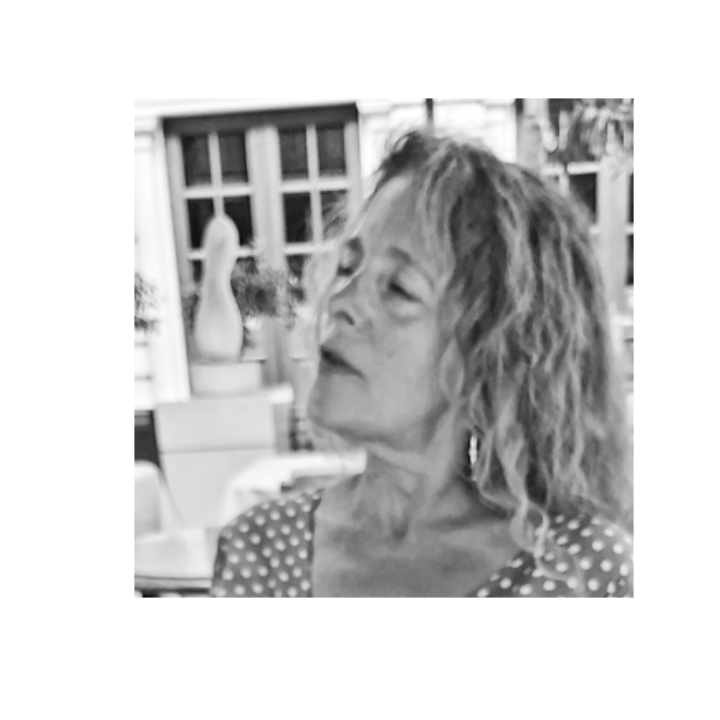

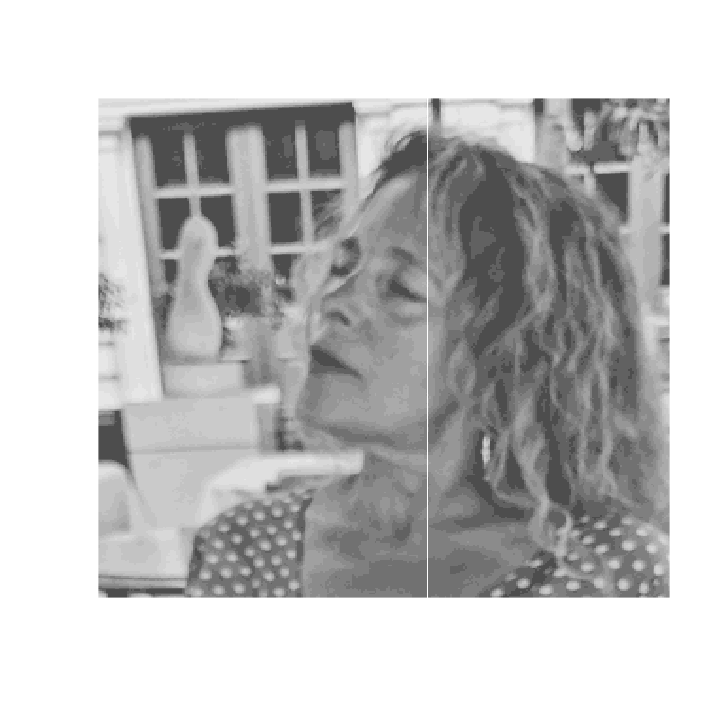

In [47]:
if(F){
system("apt-get update && apt-get install -y libmagick++-dev")
install.packages('magick')
library(magick)
}

# --- USER INPUT REQUIRED ---
image_path <- '/content/20260523_173855-01.jpeg'

input_image <- image_read(image_path)
if (length(input_image) == 0 || image_info(input_image)$format == "UNKNOWN") {
  warning("Could not read the image or it has no frames. Please ensure the file path is correct and the image format is supported (JPG/PNG recommended).")
} else {
  grayscale_image <- image_convert(input_image, type = 'Grayscale')

  # Get the current cell_size from the notebook
  current_cell_size <- cell_size # Use the existing cell_size

  # Resize the grayscale image to match the cell_size for later processing
  # The '!' ensures exact dimensions regardless of aspect ratio.
  resized_image <- image_resize(grayscale_image, paste0(current_cell_size+1, 'x', current_cell_size+1, '!'))

  # Display the resized grayscale image
  options(repr.plot.width=6, repr.plot.height=6)
  plot(resized_image, main = 'Resized Grayscale Input Image')

  # image of raw 1xNxN values to NxN integer matrix
  pixel_vector <- image_data(resized_image, 'gray')[1,,]
  image_matrix <- t(apply(matrix(as.integer(pixel_vector),current_cell_size+1),1,rev))
  image(image_matrix**2.4,axes=F,col=gray.colors(16))
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: magrittr


Attaching package: ‘imager’


The following object is masked from ‘package:magrittr’:

    add


The following objects are masked from ‘package:stats’:

    convolve, spectrum


The following object is masked from ‘package:graphics’:

    frame


The following object is masked from ‘package:base’:

    save.image




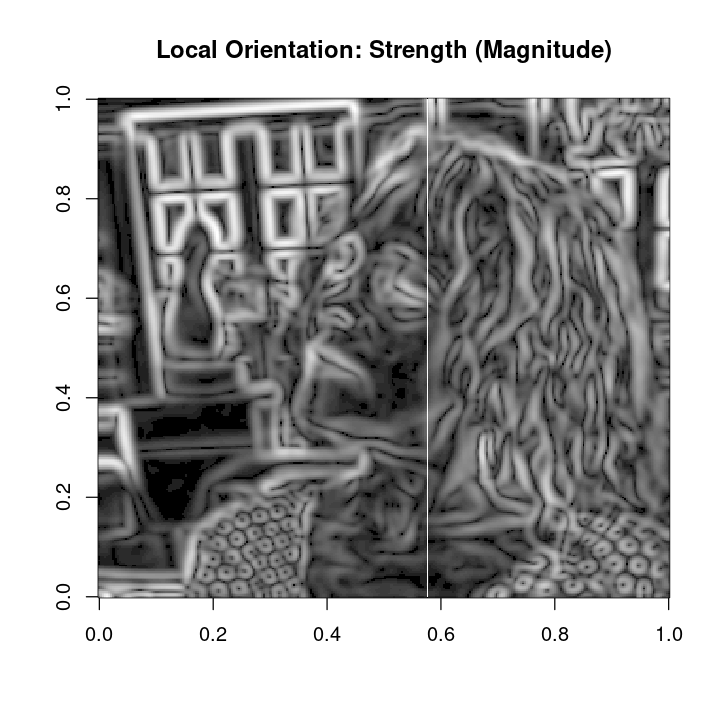

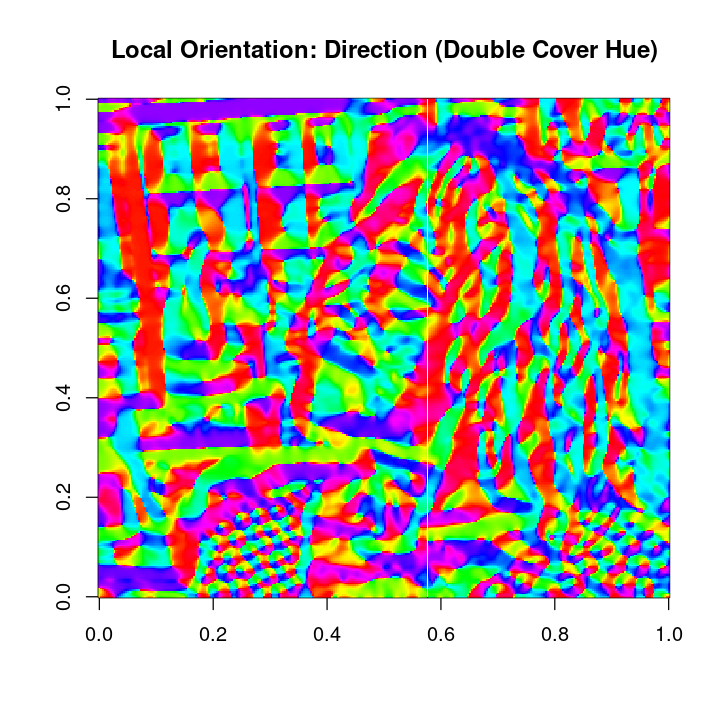

In [50]:
# Install and load imager package for image processing
if (!requireNamespace("imager", quietly = TRUE)) {
  install.packages("imager")
}
library(imager)

# Convert the integer image_matrix to a cimg object
# imager::as.cimg expects values between 0 and 255 for intensity.
# Our image_matrix has integer values in this range.
img_cimg <- as.cimg(image_matrix)

# Add a Gaussian blur to enforce consistent gradient orientation
# The 'sigma' parameter controls the strength of the blur. Adjust this value for more or less smoothing.
blur_sigma <- 2 # Example value, can be adjusted
img_cimg_blurred <- isoblur(img_cimg, sigma = blur_sigma)

# Calculate gradients (Gx and Gy) using the Sobel operator (default for imgradient)
gradients <- imgradient(img_cimg_blurred, "xy") # Use the blurred image for gradient calculation
Gx_mat <- as.matrix(gradients$x)
Gy_mat <- as.matrix(gradients$y)

# Calculate gradient magnitude (strength)
G_magnitude <- sqrt(Gx_mat^2 + Gy_mat^2)

# Calculate gradient direction (orientation) in radians (-pi to pi)
G_direction <- atan2(Gy_mat, Gx_mat)

# Apply double cover encoding for direction: map theta to 2*theta
# This transforms the range from (-pi, pi] to (-2*pi, 2*pi]
orientation_doubled <- 2 * G_direction

# Normalize the doubled orientation to a [0, 1] range for plotting hue,
# ensuring it wraps correctly for cyclical data.
# (angle + 2*pi) / (4*pi) maps -2*pi to 0 and 2*pi to 1.
normalized_orientation_for_hue <- (orientation_doubled + 2*pi) / (4*pi)
# Clamp values to ensure they are strictly within [0, 1] due to floating point inaccuracies
normalized_orientation_for_hue[normalized_orientation_for_hue < 0] <- 0
normalized_orientation_for_hue[normalized_orientation_for_hue > 1] <- 1

# --- Visualization ---
# User asked for a "vector field" representation without arrows.
# We will plot the magnitude and a hue-based representation of the double-covered direction.

# 1. Plot Magnitude (Strength)
options(repr.plot.width=6, repr.plot.height=6)
image(G_magnitude, col = gray.colors(100, start = 0, end = 1), main = "Local Orientation: Strength (Magnitude)")

# 2. Plot Direction (Double Cover) using a cyclical colormap (hue)
# Create a continuous color scale (e.g., using 'hsv' for hue) with 256 colors.
num_colors <- 256
angle_palette <- hsv(h = seq(0, 1, length.out = num_colors), s = 1, v = 1)

# Scale the normalized_orientation_for_hue values (from [0, 1])
# to map them to indices in the color palette (from [1, num_colors]).
scaled_angles <- round(normalized_orientation_for_hue * (num_colors - 1)) + 1
# Clamp values to ensure they are valid indices within the palette range.
scaled_angles[scaled_angles < 1] <- 1
scaled_angles[scaled_angles > num_colors] <- num_colors

options(repr.plot.width=6, repr.plot.height=6)
# The image function uses the numerical values in scaled_angles matrix
# as indices into the angle_palette to render the color map.
image(scaled_angles, col = angle_palette, main = "Local Orientation: Direction (Double Cover Hue)")

## Prepare Downsampled Orientation Data

### Subtask:
Downsample and smooth the `G_magnitude` and `G_direction` matrices to a `cell_size x cell_size` resolution, creating `magnitude_coarse` and `direction_coarse`.


# Task
The primary goal is to generate an artistic maze that visually aligns with the features of an input image. This involves processing an image to extract local orientation and magnitude information, downsampling this data, and then using it to influence the maze generation process by creating a dynamic mask that guides the maze's paths and obstacles. The final output will be a visualized maze where its structure reflects the underlying image features.

**Reasoning**:
Initialize `magnitude_coarse` and `direction_coarse` matrices and then populate them by iterating through the coarse grid, averaging the 2x2 blocks from the original `G_magnitude` and `G_direction` matrices using the specified double-cover method for angles.



In [ ]:
# 1. Initialize `magnitude_coarse` and `direction_coarse` as matrices of dimensions `cell_size x cell_size`.
magnitude_coarse <- matrix(0, nrow = cell_size, ncol = cell_size)
direction_coarse <- matrix(0, nrow = cell_size, ncol = cell_size)

# 2. Iterate through each (x, y) cell in the `cell_size x cell_size` grid.
for (r in 1:cell_size) {
  for (c in 1:cell_size) {
    # 3. For each (x, y) cell, define a corresponding 2x2 block in the original matrices.
    # G_magnitude and G_direction are (cell_size+1) x (cell_size+1)

    # 4. Calculate the average of the G_magnitude values within this block.
    block_magnitude <- G_magnitude[r:(r+1), c:(c+1)]
    magnitude_coarse[r, c] <- mean(block_magnitude)

    # 5. Calculate the average of the double-covered G_direction values.
    block_direction <- G_direction[r:(r+1), c:(c+1)]

    # Convert angles to their double-covered Cartesian components
    cos_doubled <- cos(2 * block_direction)
    sin_doubled <- sin(2 * block_direction)

    # Average the Cartesian components
    cos_avg <- mean(cos_doubled)
    sin_avg <- mean(sin_doubled)

    # Convert back to angle and halve it to get the averaged single-covered angle
    # atan2 gives angle in (-pi, pi], so atan2/2 naturally produces angles in (-pi/2, pi/2]
    direction_coarse[r, c] <- atan2(sin_avg, cos_avg) / 2
  }
}

# Display summary statistics or the first few values to verify
print("Summary of magnitude_coarse:")
print(summary(c(magnitude_coarse)))
print("Summary of direction_coarse:")
print(summary(c(direction_coarse)))

# Optionally, visualize the coarse magnitude and direction
options(repr.plot.width=6, repr.plot.height=6)
image(magnitude_coarse, col = gray.colors(100))
title("Coarse Magnitude")

# For direction, reuse the cyclical colormap concept
num_colors <- 256
angle_palette <- hsv(h = seq(0, 1, length.out = num_colors), s = 1, v = 1)

# Normalize direction_coarse to [0, 1] range for plotting hue. Angles are in (-pi/2, pi/2].
# Map to [0, 1] by (angle + pi/2) / pi
normalized_coarse_direction_for_hue <- (direction_coarse + pi/2) / pi
normalized_coarse_direction_for_hue[normalized_coarse_direction_for_hue < 0] <- 0
normalized_coarse_direction_for_hue[normalized_coarse_direction_for_hue > 1] <- 1

scaled_coarse_angles <- round(normalized_coarse_direction_for_hue * (num_colors - 1)) + 1
scaled_coarse_angles[scaled_coarse_angles < 1] <- 1
scaled_coarse_angles[scaled_coarse_angles > num_colors] <- num_colors

image(scaled_coarse_angles, col = angle_palette)
title("Coarse Direction (Hue)")

## Generate Artistic Mask from Orientation Data

Now, we'll create the `mask_artistic` data structure, which will guide the maze generation. The idea is:

*   **High Magnitude Areas**: Regions in the image with strong gradients (e.g., edges) will correspond to "no-mask zones" (i.e., `mask=0`), encouraging clear paths in the maze.
*   **Low Magnitude Areas**: Regions with weak gradients will be candidates for obstacles (`mask=1`). The orientation of these obstacles will be determined by the `direction_coarse`.
    *   If the local image orientation is predominantly horizontal, we'll place vertical obstacles to encourage horizontal maze paths.
    *   If the local image orientation is predominantly vertical, we'll place horizontal obstacles to encourage vertical maze paths.

In [ ]:
#f8bbdeb8
# Initialize `mask_matrix` as a `grid_size x grid_size` matrix with all 0s (initially no obstacles).
mask_matrix <- matrix(0L, nrow = grid_size, ncol = grid_size)

# Define a base probability for placing an obstacle, and how much magnitude influences it.
# A higher `magnitude_influence_factor` means strong magnitudes reduce obstacle probability more.
base_obstacle_probability <- 0.2 # Even in very low magnitude areas, there's a 70% chance of an obstacle.
magnitude_influence_factor <- 0.7 # How much magnitude reduces this probability (0 to 1)

# Max magnitude for normalization
max_G_magnitude <- max(G_magnitude)

# Define angle ranges for distinguishing horizontal and vertical orientation preferences.
# Angles close to 0 radians (e.g., between -pi/4 and pi/4) indicate horizontal preference.
# Angles close to +/- pi/2 radians indicate vertical preference.
# Note: direction_coarse is in (-pi/2, pi/2].
horizontal_angle_range <- c(-pi/4, pi/4)
vertical_angle_range_1 <- c(pi/4, pi/2) # For positive vertical angles
vertical_angle_range_2 <- c(-pi/2, -pi/4) # For negative vertical angles

# Iterate through each cell in the `cell_size x cell_size` coarse grid.
for (r_coarse in 1:cell_size) {
  for (c_coarse in 1:cell_size) {
    mag <- magnitude_coarse[r_coarse, c_coarse]
    dir <- direction_coarse[r_coarse, c_coarse]

    # Calculate probability of placing an obstacle for this cell.
    # Higher magnitude -> lower probability of obstacle.
    # Ensure mag_normalized is not NaN if max_G_magnitude is 0
    mag_normalized <- if (max_G_magnitude > 0) mag / max_G_magnitude else 0
    prob_obstacle <- base_obstacle_probability * (1 - magnitude_influence_factor * mag_normalized)

    # Use a random draw to decide if an obstacle should be placed.
    if (runif(1) < prob_obstacle) {
      # Map coarse grid indices to the central passage cell in the `grid_size` canvas.
      # A passage cell (e.g., 2*r_coarse+1, 2*c_coarse+1) has walls around it.
      passage_r <- 2 * r_coarse + 1
      passage_c <- 2 * c_coarse + 1

      # Check for dominant horizontal orientation.
      # If the image features are horizontal, we want the maze path to be horizontal.
      # This means we should make vertical walls stronger (more likely to be obstacles).
      if (dir >= horizontal_angle_range[1] && dir <= horizontal_angle_range[2]) {
        # Set vertical walls around this passage cell as obstacles.
        # Check bounds to avoid going out of matrix limits
        if (passage_c - 1 > 0) mask_matrix[passage_r, passage_c - 1] <- 1L # Left vertical wall
        if (passage_c + 1 <= grid_size) mask_matrix[passage_r, passage_c + 1] <- 1L # Right vertical wall
      }
      # Check for dominant vertical orientation.
      # If the image features are vertical, we want the maze path to be vertical.
      # This means we should make horizontal walls stronger (more likely to be obstacles).
      else if ((dir >= vertical_angle_range_1[1] && dir <= vertical_angle_range_1[2]) ||
               (dir >= vertical_angle_range_2[1] && dir <= vertical_angle_range_2[2])) {
        # Set horizontal walls around this passage cell as obstacles.
        # Check bounds
        if (passage_r - 1 > 0) mask_matrix[passage_r - 1, passage_c] <- 1L # Top horizontal wall
        if (passage_r + 1 <= grid_size) mask_matrix[passage_r + 1, passage_c] <- 1L # Bottom horizontal wall
      }
    }
  }
}

# Convert the `mask_matrix` to a `data.table` (vector) format required by `cpp_generate_maze`.
# `as.vector(t(...))` flattens the matrix column-wise, which is what R's data.tables often expect for single-column arrays.
mask <- data.table::as.data.table(as.vector(t(mask_matrix)))

### Visualize the Artistic Mask
f8bbdeb8

In [ ]:
options(repr.plot.width=8, repr.plot.height=8)
image(mask_matrix, col = gray.colors(2, start = 0, end = 1), axes = FALSE, main = "Artistic Mask (1=Obstacle, 0=Clear)")

Now that the artistic mask has been generated, we will run the `cpp_generate_maze` function using this new mask. This will produce a maze whose structure is influenced by the input image's local orientation and magnitude.